# Machine Learning: Bai thuc hanh so 4
- Trong tuần này chúng ta sẽ thực hành phương pháp K-NN và phương pháp Hồi quy SoftMax giải quyết bài toán phần loại với đầu ra có C > 2 phân lớp. 
- Phần K-NN chúng ta sẽ cố gắng dùng lại các đoạn code đã có trong các bài thực hành trước. 
- Ngoài ra, trong ví dụ cuối cùng chúng ta sẽ thử thực hiện phân loại cho một dạng dữ liệu không có cấu trúc bảng như trước, đó là dạng ảnh chữ số viết tay.
Các bạn đọc kỹ hướng dẫn và thực hiện các yêu cầu trong bài thực hành.




# Off bai thuc hanh 
- cac loai phan lop (cac chien luoc phan lop):
+ One - vs - Reset
 Vd: co 3 nhan, phan loai 3 nhan. can chia thanh 3 mat phang, can 3 x (d + 1) tham so theta
+ one - vs - one 

 Khac biet ve so luong tham so, kieu phan loai
 Xay dung ham loss de keo mien gia tri ve (0,1) -> keo ve phan loai xac suat doi voi ham phan loai don
 Doi voi nhieu nhan thi lms de phan loai => ham softmax:

 - Cau hoi lien quan den softmax trong bai thi giua ky chi co the xem o tiet ly thuet(thay day)

+ So tham so trong bai hoi quy logistic de tim ra nhan (0, 1) can bao nhieu tham so: d + 1. Muc tieu tim ra mot cai sieu phang va dung ham loss be cong no



## A. Phuong Phap KNN cho Phan loai Nhieu Lop 
- (i) Với mỗi x – unseen ở đầu vào (các phần tử trong tập Validation)
- (ii) Tính khoảng cách di từ x đến các xi trong tập Training => Lập thành 1 mảng.
- (iii) Sắp xếp các khoảng cách này theo thứ tự tăng dần, nhưng cần có tham chiếu để biết chỉ số phần
tử ban đầu trong mảng di
- (iv) Tìm ra K chỉ số của các phần tử xi trong tập Training ứng với các di nhỏ nhất. Gọi tập này là nj ,
j =1, 2, … K.
- (v) Xác định nhãn L có tần suất xuất hiện nhiều nhất trong tập đầu ra của các mẫu huấn luyện ynj. Đầu
ra dự đoán y_pred := L.
- Ở đây chúng ta chỉ cần bổ sung phương thức tìm phần tử (nhãn) có tần suất xuất hiện nhiều nhất trong tập {ynj}. Phương thức này có thể xây dựng như sau:
### Chú ý:
- Trong phương thức này đầu vào arr phải là list
- Giá trị trả về là mẫu có tần suất xuất hiện cao nhất. Ví dụ đầu vào Arr = [1, 2, 4, 2, 5, 2, 7, 9] thì giá
trị trả về là 2

In [40]:
def highest_rank(arr):
    count_num = {}
    for i in arr:
        count_num[i] = arr.count(i)
    return max(count_num, key = count_num.get)

## Vi du A.1

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
N = 500 # random data
d = 2 # so chieu
C = 3 # so lop c =0,1,2

means = [[2,2], [8,3], [3,6]] # Tam cac diem cua 3 lop c1,c2,c3
cov = [[1,0], [0,1]] # ma tran hiep phuong sai chung cho toan bo tam 

# Gen data
x0 = np.random.multivariate_normal(means[0], cov, N)
x1 = np.random.multivariate_normal(means[1], cov, N)
x2 = np.random.multivariate_normal(means[2], cov, N)

x = np.concatenate((x0, x1, x2), axis = 0).T

# Gen label for data points of each class (0,1,2)
# Tao ra N so 0, N so 1, N so 2, chuyen list ve array 
original_label = np.asarray([0]*N + [1]*N + [2]*N).T

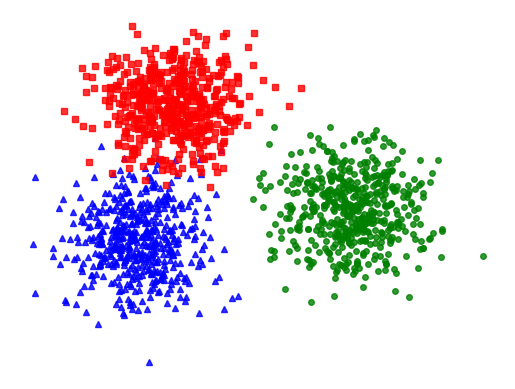

In [ ]:
def display(x, label):
    x0 = x[:, label == 0]
    x1 = x[:, label == 1]
    x2 = x[:, label == 2]
    
    plt.plot(x0[0, :], x0[1, :], 'b^', markersize = 4, alpha = .8) # blue, tam giac
    plt.plot(x1[0, :], x1[1, :], 'go', markersize = 4, alpha = .8) # gree cricle
    plt.plot(x2[0, :], x2[1, :], 'rs', markersize = 4, alpha = .8) # red square
    plt.axis("off") # an truc x, y 
    plt.plot()
    plt.show()
    
display(x[0:, :], original_label)
    

In [9]:
x_train = np.concatenate((x0[:400], x1[:400], x2[:400]), axis = 0)
y_train = np.concatenate((original_label[:400], original_label[500:900]
                        , original_label[1000:1400]), axis = 0)
x_val = np.concatenate((x0[400:], x1[400:], x2[400:]), axis = 0)
y_val = np.concatenate((original_label[400:500], original_label[900:1000],
original_label[1400:1500]), axis = 0)

print(x_train.shape, y_train.shape, x_val.shape, y_val.shape)

(1200, 2) (1200,) (300, 2) (300,)


In [34]:
def distance(array, value):
    array = np.array(array)
    return np.linalg.norm(array - value, ord = 2, axis = 1) 
    # axis: so chieu bat dau tinh tu 0

def find_nearest_index(array, value, k):
    array_D = distance(array, value)
    return np.argsort(array_D)[:k]



[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 

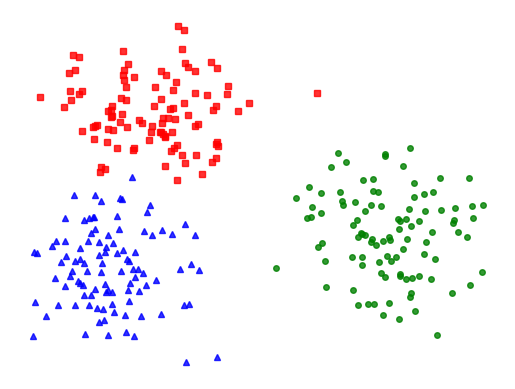

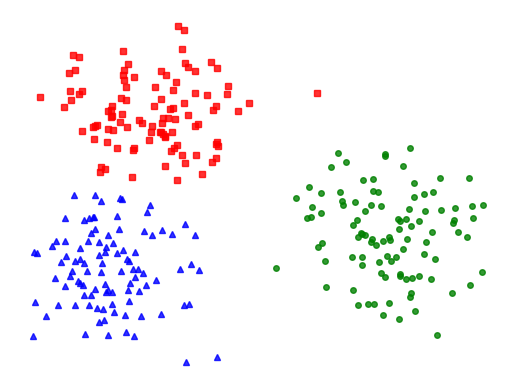

In [41]:
# Dat K = 20 va su dung pp KNN de du doan phan lop 
K = 20
y_pred = np.zeros(len(y_val)).astype(int) # tao mot array toan so 0
for j in range(len(y_val)):
    indexes = find_nearest_index(x_train, x_val[j], K)
    y_nearest = []
    for i in range(K):
        y_nearest.append(y_train[indexes[i]])
    
    y_pred[j] = highest_rank(y_nearest)
    

print(y_pred)
print(y_val)

display(x_val.T, y_val)
display(x_val.T, y_pred)

## Vi du A.2
- Trong ví dụ này chúng ta sẽ sử dụng scikit-learn sklearn với bộ dữ liệu thực phân loại hoa IRIS
theo kích thước cánh và đài hoa (https://archive.ics.uci.edu/ml/datasets/iris) .
* Thông tin về dữ liệu phân loại hoa IRIS như sau:
- Số chiều d = 4 bao gồm các thuộc tính: sepal length, sepal width, petal length, petal width;
- Các trường đều là giá trị thực(tính theo cm);
- Có tổng cộng 150 điểm dữ liệu;
- Có 03 loại (lớp – classes): setosa, versicolor, virginica , mỗi phân lớp đều có 50 mẫu. \\
- Dữ liệu được phân bố đều cho mỗi loại (mỗi phân lớp có 50 mẫu dữ liệu). Đầu tiên chúng ta sẽ load dữ liệu
và thử vẽ ra các điểm dữ liệu để có hình dung trực quan về các phân lớp của dữ liệu.
- Do dữ liệu của ta có 04 chiều nên không thể vẽ nguyên bản lên mặt phẳng. Vì vậy trong đoạn code dưới đây
chúng ta sử dụng gói PCA (Principal Components Analysis) để phân tích và chiếu dữ liệu xuống không gian
hai (02) chiều thể hiện được gần đúng nhất cấu trúc dữ liệu (thành phần chủ yếu - Principal Components

In [43]:
import pandas as pd
from sklearn.decomposition import PCA as sklearnPCA
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

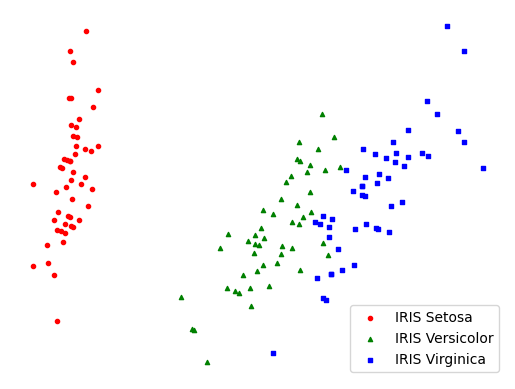

In [45]:
iris = datasets.load_iris()
x = iris.data[:, :4] 
Y = iris.target
x_norm = (x - x.min()) / (x.max() - x.min())
pca = sklearnPCA(n_components=2) #2-dimensional PCA
transformed = pd.DataFrame(pca.fit_transform(x_norm))
plt.axis("off")
plt.scatter(transformed[Y==0][0], transformed[Y==0][1], s=9, label='IRIS Setosa',
c='red')
plt.scatter(transformed[Y==1][0], transformed[Y==1][1], s=9, label='IRIS Versicolor',
c='green', marker="^")
plt.scatter(transformed[Y==2][0], transformed[Y==2][1], s=9, label='IRIS Virginica',
c='blue', marker="s")
plt.legend()
plt.show()

- Tiếp theo, hãy chia dữ liệu mỗi loại hoa thành 2 phần, 40 mẫu đầu đưa vào tập Train và 10 mẫu sau đưa vào
tập Validation. Có thể tham khảo đoạn code trong Ví dụ A.1., tuy nhiên cần chú ý chọn chiều (axis) phù hợp.
- Sử dụng chương trình cho phương pháp K-NN đã có và dựa vào tập Train, thực hiện dự đoán phân loại các
mẫu trong tập Validation. Sử dụng các độ đo như Accuracy, Precision, Confusion Matrix để đánh giá độ chính
xác của phương pháp.